In [1]:
print("Работает")

Работает


In [1]:
import pandas as pd

xl = pd.ExcelFile('../data/raw/умное_потребление_данные.xlsx')
print(xl.sheet_names)

['README', 'Romir_ИПУ', 'Romir_Кошелек', 'Демография_Сегменты', 'Домохозяйства_Профили', 'NoBuy_Опрос', 'СберИндекс_Динамика', 'СберИндекс_Категории', 'СберИндекс_Офлайн', 'СберПро_Тренды2025', 'Теория_Формула', 'Флаги', 'STM_Опыт_Покупок', 'STM_Топ_Категорий', 'STM_Мотивация', 'Rosstat_Оборот_Розницы']


In [2]:
import sqlite3

# Словарь: лист Excel → таблица в SQLite
sheets = {
    'Romir_ИПУ':              'consumer_confidence',
    'Romir_Кошелек':          'wallet_metrics',
    'Демография_Сегменты':    'demographics',
    'Домохозяйства_Профили':  'household_profiles',
    'NoBuy_Опрос':            'nobuy_survey',
    'СберИндекс_Динамика':    'sberindex_dynamics',
    'СберИндекс_Категории':   'sberindex_categories',
    'СберИндекс_Офлайн':      'sberindex_offline',
    'СберПро_Тренды2025':     'sberpro_trends',
    'Теория_Формула':         'theory_formulas',
    'Флаги':                  'data_flags',
    'STM_Опыт_Покупок':       'stm_experience',
    'STM_Топ_Категорий':      'stm_categories',
    'STM_Мотивация':          'stm_motivation',
    'Rosstat_Оборот_Розницы': 'retail_turnover',
}

conn = sqlite3.connect('../data/smart_consumption.db')

for sheet, table in sheets.items():
    df = pd.read_excel(xl, sheet_name=sheet)
    df = df.dropna(axis=1, how='all')   # убрать пустые столбцы
    df = df.dropna(axis=0, how='all')   # убрать пустые строки
    df.columns = [str(c).strip().lower().replace(' ', '_') for c in df.columns]
    df.to_sql(table, conn, if_exists='replace', index=False)
    print(f"{sheet:30s} → {table:30s} | {len(df)} строк")

conn.close()
print("\n✅ База сохранена: data/smart_consumption.db")

Romir_ИПУ                      → consumer_confidence            | 14 строк
Romir_Кошелек                  → wallet_metrics                 | 8 строк
Демография_Сегменты            → demographics                   | 3 строк
Домохозяйства_Профили          → household_profiles             | 5 строк
NoBuy_Опрос                    → nobuy_survey                   | 50 строк
СберИндекс_Динамика            → sberindex_dynamics             | 7 строк
СберИндекс_Категории           → sberindex_categories           | 18 строк
СберИндекс_Офлайн              → sberindex_offline              | 28 строк
СберПро_Тренды2025             → sberpro_trends                 | 3 строк
Теория_Формула                 → theory_formulas                | 7 строк
Флаги                          → data_flags                     | 3 строк
STM_Опыт_Покупок               → stm_experience                 | 6 строк
STM_Топ_Категорий              → stm_categories                 | 10 строк
STM_Мотивация                  → 

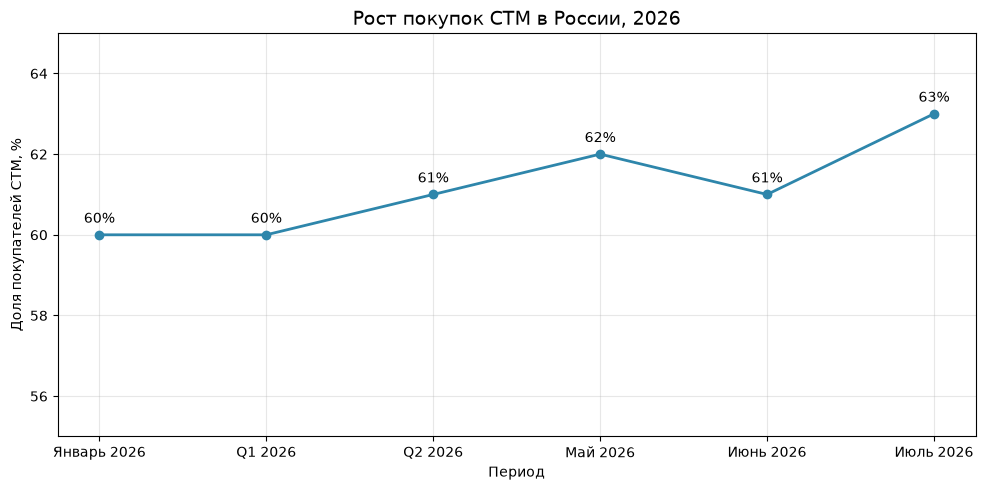

In [3]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('../data/smart_consumption.db')

query = """
SELECT period, regular_or_sometimes_total_pct
FROM stm_experience
ORDER BY 
    CASE period
        WHEN 'Январь 2026' THEN 1
        WHEN 'Q1 2026'     THEN 2
        WHEN 'Q2 2026'     THEN 3
        WHEN 'Май 2026'    THEN 4
        WHEN 'Июнь 2026'   THEN 5
        WHEN 'Июль 2026'   THEN 6
    END
"""

df = pd.read_sql(query, conn)
conn.close()

plt.figure(figsize=(10, 5))
plt.plot(df['period'], df['regular_or_sometimes_total_pct'], 
         marker='o', linewidth=2, color='#2E86AB')
plt.title('Рост покупок СТМ в России, 2026', fontsize=14)
plt.xlabel('Период')
plt.ylabel('Доля покупателей СТМ, %')
plt.ylim(55, 65)
plt.grid(alpha=0.3)

for i, v in enumerate(df['regular_or_sometimes_total_pct']):
    plt.text(i, v + 0.3, f'{v}%', ha='center')

plt.tight_layout()
plt.savefig('../visualizations/stm_dynamics.png', dpi=150)
plt.show()

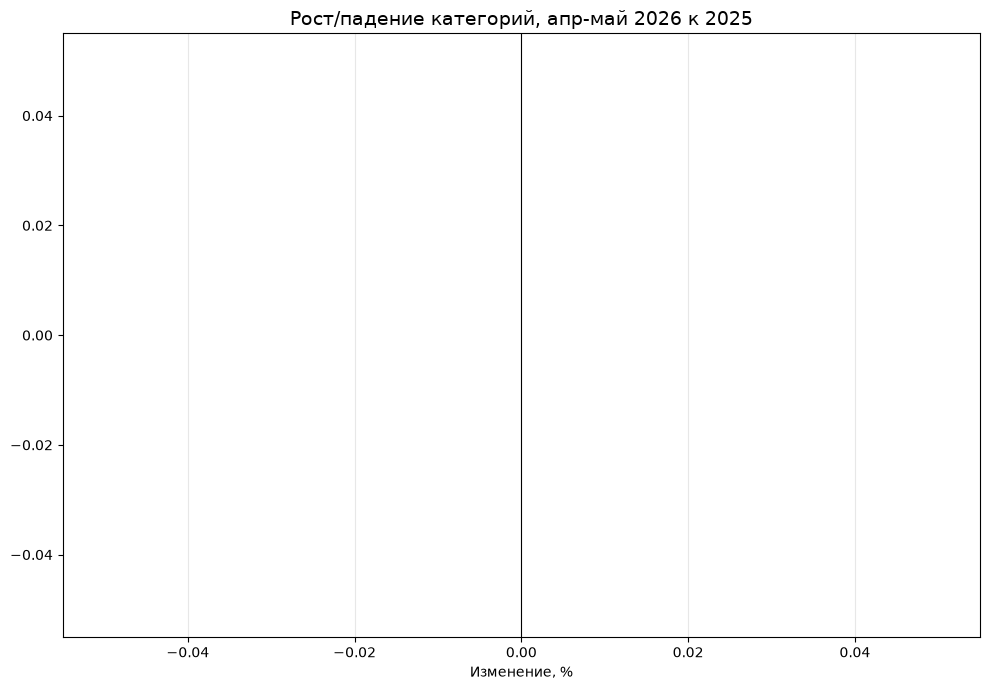

In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('../data/smart_consumption.db')

query = """
SELECT category, growth_pct_apr_may_2026
FROM sberindex_categories
WHERE category LIKE 'из них:%'
ORDER BY growth_pct_apr_may_2026 ASC
"""

df = pd.read_sql(query, conn)
conn.close()

# Обрезаем длинные названия
df['category'] = df['category'].str.replace('из них: ', '').str[:25]

# Цвета: красные для падения, зелёные для роста
colors = ['#E63946' if x < 0 else '#2E86AB' for x in df['growth_pct_apr_may_2026']]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(df['category'], df['growth_pct_apr_may_2026'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Рост/падение категорий, апр-май 2026 к 2025', fontsize=14)
ax.set_xlabel('Изменение, %')
ax.grid(alpha=0.3, axis='x')

for i, v in enumerate(df['growth_pct_apr_may_2026']):
    ax.text(v + (0.5 if v > 0 else -0.5), i, f'{v}%', 
            va='center', ha='left' if v > 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('../visualizations/categories_change.png', dpi=150)
plt.show()

In [5]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('../data/smart_consumption.db')
df = pd.read_sql("SELECT category, growth_pct_apr_may_2026 FROM sberindex_categories WHERE category LIKE 'из них:%'", conn)
conn.close()

print("Типы данных:")
print(df.dtypes)
print()
print("Первые 5 строк:")
print(df.head())
print()
print("Проверка на числа:")
print(df['growth_pct_apr_may_2026'].apply(type).value_counts())

Типы данных:
category                   object
growth_pct_apr_may_2026    object
dtype: object

Первые 5 строк:
Empty DataFrame
Columns: [category, growth_pct_apr_may_2026]
Index: []

Проверка на числа:
Series([], Name: count, dtype: int64)


In [6]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('../data/smart_consumption.db')

# Без WHERE — берём все строки
df = pd.read_sql("SELECT category, growth_pct_apr_may_2026 FROM sberindex_categories", conn)
conn.close()

print(f"Всего строк: {len(df)}")
print(df.to_string())

Всего строк: 18
                                   category  growth_pct_apr_may_2026
0                         Продовольственные                      8.0
1               Непродовольственные (всего)                     15.0
2                      из них: Маркетплейсы                     33.0
3                           из них: Топливо                      5.0
4             из них: Лекарства и медтовары                      9.0
5        из них: Товары для стройки/ремонта                     -6.0
6         из них: Одежда, обувь, аксессуары                     -3.0
7                   из них: Бытовая техника                     -5.0
8     из них: Товары для красоты и здоровья                      4.0
9       из них: Мебель и предметы интерьера                     -9.0
10                           Услуги (всего)                     14.0
11                              из них: ЖКУ                     21.0
12               из них: Медицинские услуги                     12.0
13    из них: Такс

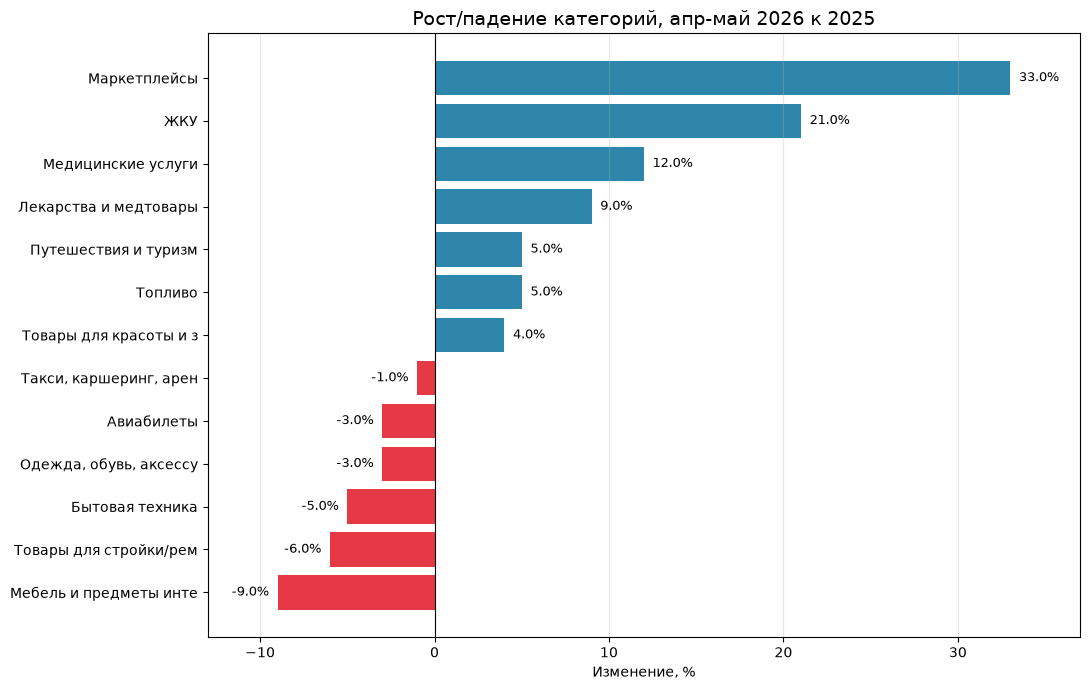

In [10]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('../data/smart_consumption.db')
df = pd.read_sql("SELECT category, growth_pct_apr_may_2026 FROM sberindex_categories", conn)
conn.close()

# Числа
df['growth_pct_apr_may_2026'] = pd.to_numeric(df['growth_pct_apr_may_2026'], errors='coerce')

# Фильтр подкатегорий
df = df[df['category'].str.contains('из них', na=False, regex=False)].copy()

# Чистим название и обрезаем до 22 символов
df['category'] = (df['category']
                  .str.replace('из них:', '', regex=False)
                  .str.strip()
                  .str[:22])

# Сортировка
df = df.sort_values('growth_pct_apr_may_2026')

# Цвета
colors = ['#E63946' if x < 0 else '#2E86AB' for x in df['growth_pct_apr_may_2026']]

# График с широким левым полем
fig, ax = plt.subplots(figsize=(11, 7))
fig.subplots_adjust(left=0.28)

ax.barh(df['category'], df['growth_pct_apr_may_2026'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Рост/падение категорий, апр-май 2026 к 2025', fontsize=14)
ax.set_xlabel('Изменение, %')
ax.grid(alpha=0.3, axis='x')

# Подписи: справа для плюсов, слева для минусов
for i, v in enumerate(df['growth_pct_apr_may_2026']):
    if v > 0:
        ax.text(v + 0.5, i, f'{v}%', va='center', ha='left', fontsize=9)
    else:
        ax.text(v - 0.5, i, f'{v}%', va='center', ha='right', fontsize=9)

# Запас по краям, чтобы подписи не вылезали
ax.set_xlim(df['growth_pct_apr_may_2026'].min() - 4,
            df['growth_pct_apr_may_2026'].max() + 4)

plt.tight_layout()
plt.savefig('../visualizations/categories_change.png', dpi=150)
plt.show()